In [4]:
import astropy

print(astropy.__version__)

8.0.1


In [5]:
from astropy.io import ascii

In [56]:
tbl = ascii.read("resources/simple_table.csv")

In [55]:
import os

print(os.getcwd())

e:\astronomy-data-python\Jupyter


In [8]:
tbl

name,ra,dec
str6,str10,str9
BLG100,17:51:00.0,-29:59:48
BLG101,17:53:40.2,-29:49:52
BLG102,17:56:20.2,-29:30:51
BLG103,17:56:20.2,-30:06:22


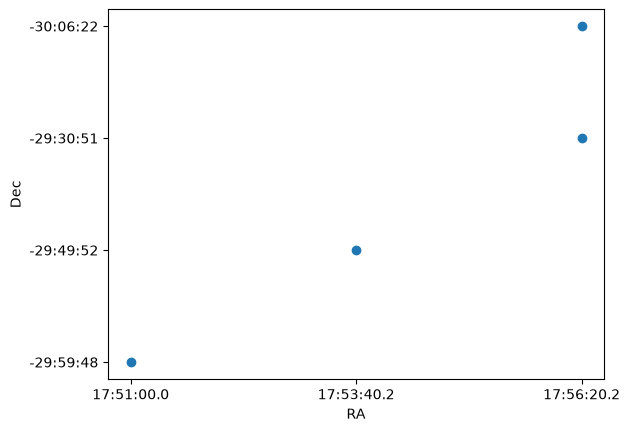

In [9]:
import matplotlib.pyplot as plt

plt.scatter(tbl["ra"], tbl["dec"])
plt.xlabel("RA")
plt.ylabel("Dec")
plt.show()

In [10]:
from astropy.coordinates import SkyCoord
import astropy.units as u

In [11]:
coords = SkyCoord(
    tbl["ra"],
    tbl["dec"],
    unit=(u.hourangle, u.deg)
)

coords

<SkyCoord (ICRS): (ra, dec) in deg
    [(267.75      , -29.99666667), (268.4175    , -29.83111111),
     (269.08416667, -29.51416667), (269.08416667, -30.10611111)]>

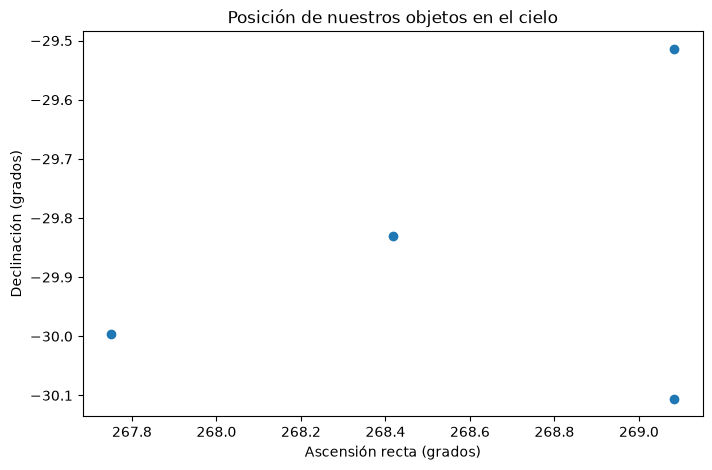

In [13]:
plt.figure(figsize=(8, 5))

plt.scatter(coords.ra.deg, coords.dec.deg)

plt.xlabel("Ascensión recta (grados)")
plt.ylabel("Declinación (grados)")
plt.title("Posición de nuestros objetos en el cielo")

plt.show()

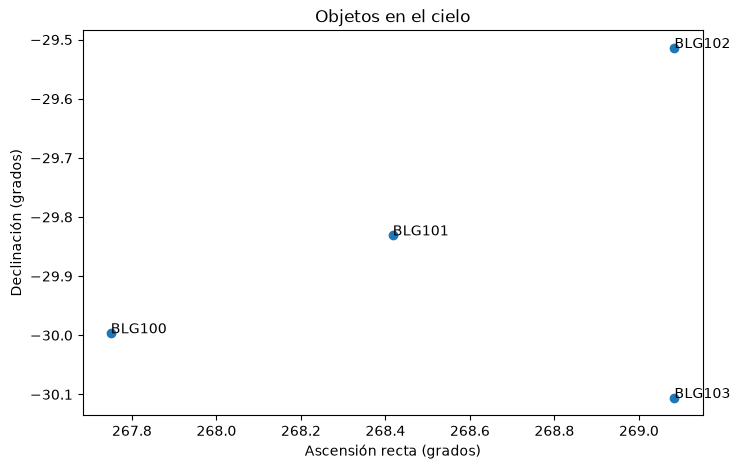

In [14]:
plt.figure(figsize=(8, 5))

plt.scatter(coords.ra.deg, coords.dec.deg)

for name, ra, dec in zip(tbl["name"], coords.ra.deg, coords.dec.deg):
    plt.text(ra, dec, name)

plt.xlabel("Ascensión recta (grados)")
plt.ylabel("Declinación (grados)")
plt.title("Objetos en el cielo")

plt.show()

In [15]:
for x in zip(tbl["name"], coords.ra.deg, coords.dec.deg):
    print(x)

(np.str_('BLG100'), np.float64(267.75), np.float64(-29.996666666666666))
(np.str_('BLG101'), np.float64(268.41749999999996), np.float64(-29.83111111111111))
(np.str_('BLG102'), np.float64(269.08416666666665), np.float64(-29.514166666666668))
(np.str_('BLG103'), np.float64(269.08416666666665), np.float64(-30.10611111111111))


In [16]:
tbl.colnames

['name', 'ra', 'dec']

In [17]:
tbl.info()

<Table length=4>
name dtype
---- -----
name  str6
  ra str10
 dec  str9


In [18]:
tbl.colnames
tbl.info()

<Table length=4>
name dtype
---- -----
name  str6
  ra str10
 dec  str9


In [19]:
tbl["name"]

BLG100
BLG101
BLG102
BLG103


In [20]:
tbl["name"][0]

np.str_('BLG100')

In [57]:
young = ascii.read(
    "resources/Young-Objects-Compilation.csv",
    header_start=1,
    data_start=2
)

In [22]:
import os

print(os.getcwd())

e:\astronomy-data-python\Jupyter


In [23]:
young

Name,Designation,RA,Dec,Jmag,J_unc,Hmag,H_unc,Kmag,K_unc,W1,W1_unc,W2,W2_unc,W3,W3_unc,W4,W4_unc,Spectral Type,Spectra (FITS),Opt Spec Refs,NIR Spec Refs,pm_ra (mas),pm_ra_unc,pm_dec (mas),pm_dec_unc,pi (mas),pi_unc,radial velocity (km/s),rv_unc,Astrometry Refs,Discovery Refs,Group/Age,Note
str24,str25,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str4,float64,str4,str6,int64,str26,str23,float64,float64,float64,float64,float64,float64,int64,int64,str19,str23,int64,str38
--,00 04 02.84 -64 10 35.6,1.01201,-64.18,15.79,0.07,14.83,0.07,14.01,0.05,13.37,0.03,12.94,0.03,12.18,0.24,9.16,null,L1Î³,--,Kirkpatrick et al. 2010,--,--,--,--,--,--,--,--,--,--,Kirkpatrick et al. 2010,--,--
PC 0025+04,00 27 41.97 +05 03 41.7,6.92489,5.06,16.19,0.09,15.29,0.1,14.96,0.12,14.62,0.04,14.14,0.05,12.24,null,8.89,null,M9.5Î²,--,Mould et al. 1994,--,0.0105,0.0004,-0.0008,0.0003,--,--,--,--,Faherty et al. 2009,Schneider et al. 1991,--,--
--,00 32 55.84 -44 05 05.8,8.23267,-44.08,14.78,0.04,13.86,0.03,13.27,0.04,12.82,0.03,12.49,0.03,11.73,0.19,9.29,null,L0Î³,--,Cruz et al. 2009,--,0.1178,0.0043,-0.0916,0.0043,38.4,4.8,--,--,Faherty et al. 2012,Reid et al. 2008,--,--
--,00 37 43.06 -58 46 22.9,9.42942,-58.77,15.37,0.05,14.26,0.05,13.59,0.05,13.13,0.03,12.74,0.03,12.56,0.38,9.32,null,L0Î³,--,Cruz et al. 2009,--,0.049,0.01,-0.051,0.02,--,--,--,--,Faherty et al. 2009,Reid et al. 2008,--,--
--,00 45 21.43 +16 34 44.6,11.33929,16.58,13.06,0.02,12.06,0.04,11.37,0.02,10.77,0.02,10.39,0.02,9.74,0.04,8.42,0.26,L2Î²,--,Cruz et al. 2009,Wilson et al. 2003,0.385,0.017,-0.026,0.012,--,--,--,--,Faherty et al. 2009,Wilson et al. 2003,--,--
--,Empire,--,--,13.8,--,13.1,--,12.5,--,12.07,0.03,11.64,0.02,11.14,0.18,9.02,null,M9Î²,--,Reid et al. 2008,Wilson et al. 2003,0.098,0.022,-0.051,0.01,--,--,--,--,Faherty et al. 2009,Wilson et al. 2003,--,--
--,Flatiron,--,--,16.4,0.1,15.2,--,14.4,--,13.68,0.03,13.2,0.03,11.99,null,8.48,null,L2Î³,--,Cruz et al. in prep,Cruz et al. in prep,0.044,0.024,-0.082,0.024,--,--,--,--,Faherty et al. 2009,Cruz et al. in prep,--,--
--,Liberty,--,--,15.1,--,14.2,--,13.4,--,13.03,0.03,12.62,0.03,11.8,0.19,9.22,null,L1Î²,--,Cruz et al. in prep,Cruz et al. in prep,0.08,0.017,-0.062,0.02,--,--,--,--,Faherty et al. 2009,Cruz et al. 2003,--,--
--,01 24 45.99 -57 45 37.9,21.19163,-57.76,16.31,0.11,15.06,0.09,14.32,0.09,13.77,0.03,13.34,0.03,12.45,0.31,8.91,null,L0Î³,--,Cruz et al. 2009,--,-0.003,0.01,0.018,0.019,--,--,--,--,Faherty et al. 2009,Reid et al. 2008,--,--


In [24]:
print("Filas:", len(young))
print("Columnas:", len(young.colnames))
young.info() 

Filas: 64
Columnas: 34
<Table length=64>
         name           dtype     class     n_bad
---------------------- ------- ------------ -----
                  Name   str24 MaskedColumn    54
           Designation   str25       Column     0
                    RA float64 MaskedColumn    17
                   Dec float64 MaskedColumn    17
                  Jmag float64       Column     0
                 J_unc float64 MaskedColumn    16
                  Hmag float64       Column     0
                 H_unc float64 MaskedColumn    18
                  Kmag float64       Column     0
                 K_unc float64 MaskedColumn    18
                    W1 float64       Column     0
                W1_unc float64       Column     0
                    W2 float64       Column     0
                W2_unc float64       Column     0
                    W3 float64       Column     0
                W3_unc    str4       Column     0
                    W4 float64       Column     0
         

In [25]:
young.colnames

['Name',
 'Designation',
 'RA',
 'Dec',
 'Jmag',
 'J_unc',
 'Hmag',
 'H_unc',
 'Kmag',
 'K_unc',
 'W1',
 'W1_unc',
 'W2',
 'W2_unc',
 'W3',
 'W3_unc',
 'W4',
 'W4_unc',
 'Spectral Type',
 'Spectra (FITS)',
 'Opt Spec Refs',
 'NIR Spec Refs',
 'pm_ra (mas)',
 'pm_ra_unc',
 'pm_dec (mas)',
 'pm_dec_unc',
 'pi (mas)',
 'pi_unc',
 'radial velocity (km/s)',
 'rv_unc',
 'Astrometry Refs',
 'Discovery Refs',
 'Group/Age',
 'Note']

In [26]:
young[0]

Name,Designation,RA,Dec,Jmag,J_unc,Hmag,H_unc,Kmag,K_unc,W1,W1_unc,W2,W2_unc,W3,W3_unc,W4,W4_unc,Spectral Type,Spectra (FITS),Opt Spec Refs,NIR Spec Refs,pm_ra (mas),pm_ra_unc,pm_dec (mas),pm_dec_unc,pi (mas),pi_unc,radial velocity (km/s),rv_unc,Astrometry Refs,Discovery Refs,Group/Age,Note
str24,str25,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str4,float64,str4,str6,int64,str26,str23,float64,float64,float64,float64,float64,float64,int64,int64,str19,str23,int64,str38
--,00 04 02.84 -64 10 35.6,1.01201,-64.18,15.79,0.07,14.83,0.07,14.01,0.05,13.37,0.03,12.94,0.03,12.18,0.24,9.16,null,L1Î³,--,Kirkpatrick et al. 2010,--,--,--,--,--,--,--,--,--,--,Kirkpatrick et al. 2010,--,--


In [27]:
# ¿Qué objeto del catálogo es el más brillante en la banda J?
young["Jmag"].min()

# ¿Su Jmag es igual al mínimo?"
young[young["Jmag"] == young["Jmag"].min()]

Name,Designation,RA,Dec,Jmag,J_unc,Hmag,H_unc,Kmag,K_unc,W1,W1_unc,W2,W2_unc,W3,W3_unc,W4,W4_unc,Spectral Type,Spectra (FITS),Opt Spec Refs,NIR Spec Refs,pm_ra (mas),pm_ra_unc,pm_dec (mas),pm_dec_unc,pi (mas),pi_unc,radial velocity (km/s),rv_unc,Astrometry Refs,Discovery Refs,Group/Age,Note
str24,str25,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str4,float64,str4,str6,int64,str26,str23,float64,float64,float64,float64,float64,float64,int64,int64,str19,str23,int64,str38
LP 944- 20/BRI 0337-3535,03 39 35.2 -35 25 44,54.89674,-35.43,10.73,0.02,10.02,0.02,9.55,0.02,9.13,0.02,8.81,0.02,8.27,0.02,8.0,0.11,M9Î²,--,KHI97,Geballe et al. 2002,0.324,0.0076,0.2959,0.0075,--,--,--,--,Faherty et al. 2009,Luyten 1979 (NLTT)**,--,--


In [28]:
# Indice de calor
color_JK = young["Jmag"] - young["Kmag"]
color_JK

1.7799999999999994
1.2300000000000004
1.5099999999999998
1.7799999999999994
1.6900000000000013
1.3000000000000007
1.9999999999999982
1.6999999999999993
1.9899999999999984
1.8000000000000007
1.7300000000000004


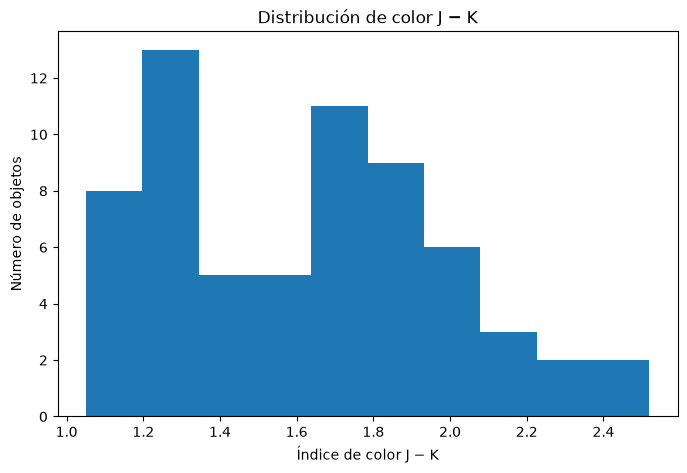

In [29]:
plt.figure(figsize=(8, 5))

plt.hist(color_JK, bins=10)

plt.xlabel("Índice de color J − K")
plt.ylabel("Número de objetos")
plt.title("Distribución de color J − K")

plt.show()

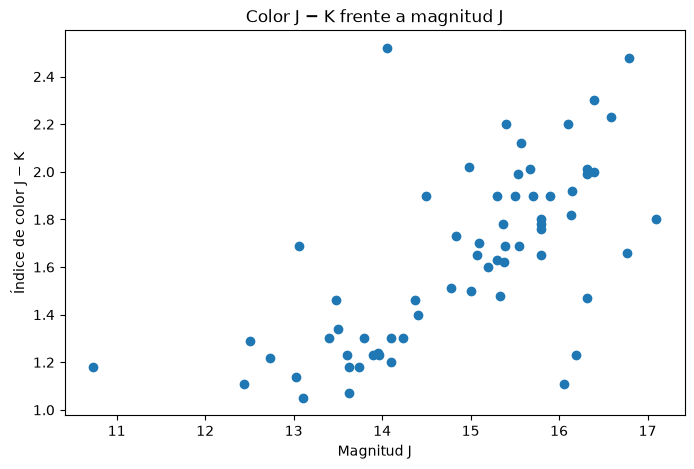

In [30]:
plt.figure(figsize=(8, 5))

plt.scatter(young["Jmag"], color_JK)

plt.xlabel("Magnitud J")
plt.ylabel("Índice de color J − K")
plt.title("Color J − K frente a magnitud J")

plt.show()

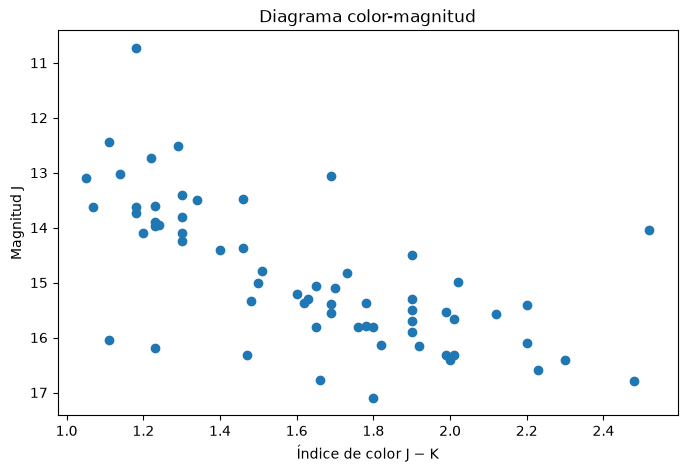

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(color_JK, young["Jmag"])

plt.xlabel("Índice de color J − K")
plt.ylabel("Magnitud J")

plt.title("Diagrama color-magnitud")

plt.ylim(reversed(plt.ylim()))

plt.show()

# el color J−K nos da información sobre la temperatura/espectro de los objetos, mientras que la magnitud nos habla de su brillo observado

In [41]:
import numpy as np
import astropy.units as u
from astropy import coordinates as coord


In [43]:
ra = coord.Angle(young["RA"].filled(np.nan) * u.degree)
ra = ra.wrap_at(180 * u.degree)

dec = coord.Angle(young["Dec"].filled(np.nan) * u.degree)

In [44]:
print(ra)
print(dec)

[1d00m43.236s 6d55m29.604s 8d13m57.612s 9d25m45.912s 11d20m21.444s nan nan
 nan 21d11m29.868s 21d31m39s 25d29m33.468s nan 35d28m44.112s 35d58m39.612s
 36d19m52.068s 38d30m13.968s 40d17m52.692s 43d29m57.012s 45d50m06.36s
 50d47m30.3s nan 54d53m48.264s 58d50m50.568s 59d21m44.244s 61d36m41.616s
 65d16m48.108s 69d06m58.356s 70d54m24.12s 75d21m00.9s nan nan 83d33m59.22s
 nan 92d13m12.576s 103d12m07.668s 108d09m27.9s nan 155d31m13.368s
 155d42m03.168s 165d32m27.492s nan -147d09m40.356s nan nan -123d03m12.132s
 -122d01m54.444s -121d45m14.112s -120d32m28.284s -116d04m21.972s nan
 -98d29m58.956s -66d01m00.768s -60d48m15.012s -59d47m53.844s nan
 -56d32m07.188s -38d17m24s nan nan -27d56m35.556s -26d33m46.26s
 -17d31m38.172s nan -9d16m45.156s]
[-64d10m48s 5d03m36s -44d04m48s -58d46m12s 16d34m48s nan nan nan
 -57d45m36s 14d28m12s -46d34m12s nan -54d12m00s -58d15m00s -58d37m12s
 -64d42m00s -3d27m00s 32d06m36s -73d12m36s -46d31m12s nan -35d25m48s
 11d33m36s -44d17m24s -38d12m00s -63d06m00s -41d15m00s

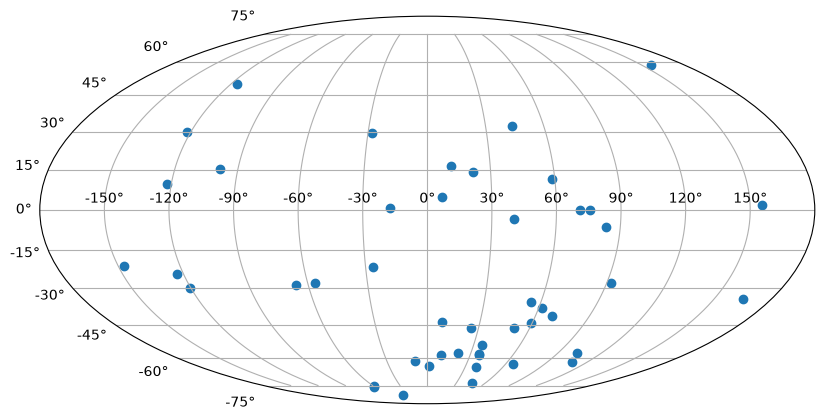

In [ ]:
# mapa del cielo en proyección Mollweide
plt.figure(figsize=(10, 6))
plt.subplot(111, projection="mollweide")
plt.scatter(ra.radian, dec.radian)
plt.grid(True)
plt.show()

In [48]:
print(ra.unit)
print(dec.unit)

deg
deg


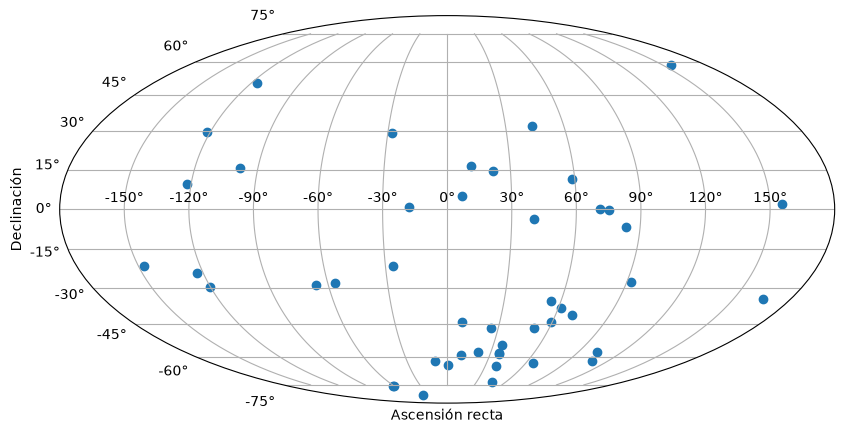

In [49]:
plt.figure(figsize=(10, 6))

ax = plt.subplot(111, projection="mollweide")

ax.scatter(ra.radian, dec.radian)

ax.set_xlabel("Ascensión recta")
ax.set_ylabel("Declinación")

ax.grid(True)

plt.show()

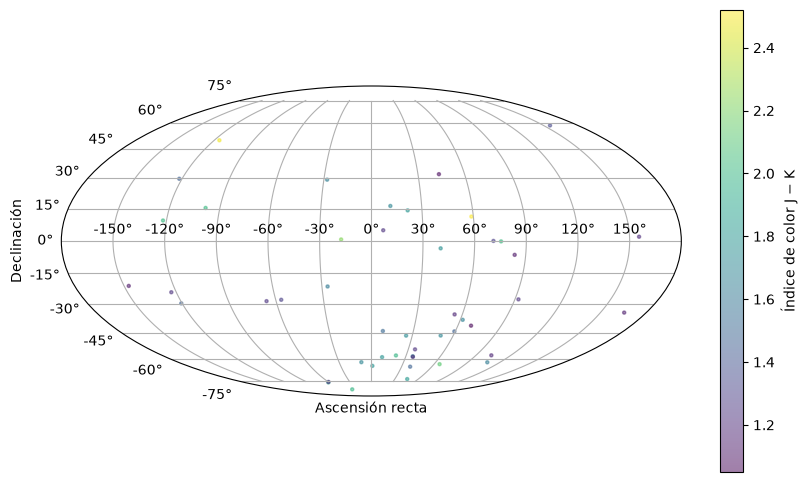

In [ ]:
plt.figure(figsize=(10, 6))

ax = plt.subplot(111, projection="mollweide")

scatter = ax.scatter(
    ra.radian,
    dec.radian,
    s=5,
    alpha=0.5,
    c=color_JK
)

ax.set_xlabel("Ascensión recta")
ax.set_ylabel("Declinación")

ax.grid(True)

plt.colorbar(scatter, label="Índice de color J − K")

plt.show()

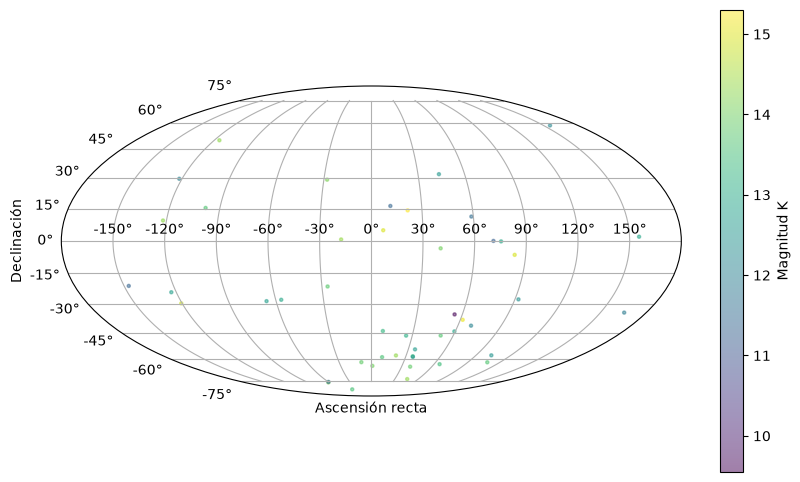

In [52]:
plt.figure(figsize=(10, 6))

ax = plt.subplot(111, projection="mollweide")

scatter = ax.scatter(
    ra.radian,
    dec.radian,
    s=5,
    alpha=0.5,
    c=young["Kmag"]
)

ax.set_xlabel("Ascensión recta")
ax.set_ylabel("Declinación")

ax.grid(True)

plt.colorbar(scatter, label="Magnitud K")

plt.show()